# Targeted calibration — scenario A

Grid search over 27 combinations:
- `f0_max ∈ {0.85, 0.88, 0.90}`
- `k_sigmoid ∈ {25, 40, 60}`
- `γ (difficulty bonus) ∈ {1.0, 2.0, 3.0}`

Targets to satisfy simultaneously:
- **R₁** honest / mediocre ratio ∈ [3, 10]
- **R₂** honest / cherry-picker ratio > 5 (ideally > 10)
- **R₃** mediocre / cherry-picker ratio > 1
- **R₄** honest / sybil ratio > 100

Data: `simulateur/calibration/grid_search_A.csv`.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

plt.rcParams["figure.figsize"] = (12, 4)
plt.rcParams["axes.grid"] = False

CSV = os.path.abspath(os.path.join(os.getcwd(), "..", "calibration", "grid_search_A.csv"))
df = pd.read_csv(CSV)
df.head(3)

,f0_max,k_sigmoid,gamma,gain_honnete,gain_mediocre,gain_cherry_picker,gain_sybil,gain_random_biased,ratio_h_m,ratio_h_c,ratio_m_c,ratio_h_s,passes_h_m,passes_h_c,passes_m_c,passes_h_s,n_passed,results_dir
0,0.85,25.0,1.0,696808.264061,269568.010737,456650.119740,2293.334656,3261.141563,2.584907,1.525913,0.590316,303.840638,False,False,False,True,1,simulateur/results/grid_A_f0.85_k25_g1.0/20260...
1,0.85,25.0,2.0,846928.422762,331499.126712,519401.130346,2859.785701,4048.941873,2.554844,1.630586,0.638233,296.151010,False,False,False,True,1,simulateur/results/grid_A_f0.85_k25_g2.0/20260...
2,0.85,25.0,3.0,994352.512017,392318.950517,580997.963244,3417.656924,4826.549414,2.534551,1.711456,0.675250,290.945678,False,False,False,True,1,simulateur/results/grid_A_f0.85_k25_g3.0/20260...


## §1 — Global diagnostic

In [2]:
print(f"Total combinations      : {len(df)}")
print(f"Satisfy 4/4 targets     : {(df['n_passed'] == 4).sum()}")
print(f"Satisfy 3/4 targets     : {(df['n_passed'] == 3).sum()}")
print(f"Satisfy 2/4 targets     : {(df['n_passed'] == 2).sum()}")
print()
print("Range of ratios obtained on the grid:")
print(f"  ratio_h_m : {df.ratio_h_m.min():>6.2f} → {df.ratio_h_m.max():>6.2f}   [target: 3 to 10]")
print(f"  ratio_h_c : {df.ratio_h_c.min():>6.2f} → {df.ratio_h_c.max():>6.2f}   [target: > 5]")
print(f"  ratio_m_c : {df.ratio_m_c.min():>6.2f} → {df.ratio_m_c.max():>6.2f}   [target: > 1]")
print(f"  ratio_h_s : {df.ratio_h_s.min():>6.0f} → {df.ratio_h_s.max():>6.0f}   [target: > 100]")

Total combinations      : 27
Satisfy 4/4 targets     : 0
Satisfy 3/4 targets     : 0
Satisfy 2/4 targets     : 21

Range of ratios obtained on the grid:
  ratio_h_m :   2.53 →  14.00   [target: 3 to 10]
  ratio_h_c :   1.13 →   1.78   [target: > 5]
  ratio_m_c :   0.08 →   0.68   [target: > 1]
  ratio_h_s :    291 →   3057   [target: > 100]


**Immediate diagnostic**:
- `ratio_h_s > 100` is satisfied by all 27 combinations. Good news: the anti-sybil defense is never broken in this parameter range.
- `ratio_h_m ∈ [3, 10]` is partially achieved depending on the combination.
- **`ratio_h_c > 5`**: *never reached*, max 1.78. The cherry-picker stays at ~60 % of the honest gain at best.
- **`ratio_m_c > 1`**: *never reached*, max 0.68. The mediocre stays systematically below the cherry-picker.

Conclusion: **no combination satisfies the 4 targets simultaneously**. The bottleneck is structural on the cherry-picker axis.

## §2 — Heatmaps of the 4 ratios

Each ratio in a grid `f0_max × k_sigmoid`, one column per γ value. Cell framed in green = criterion met.

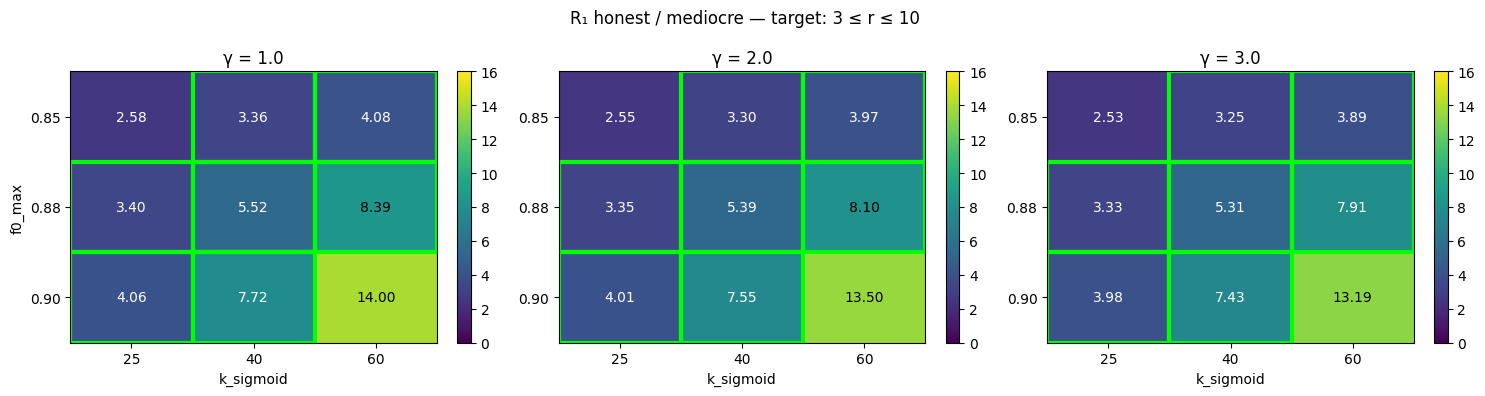

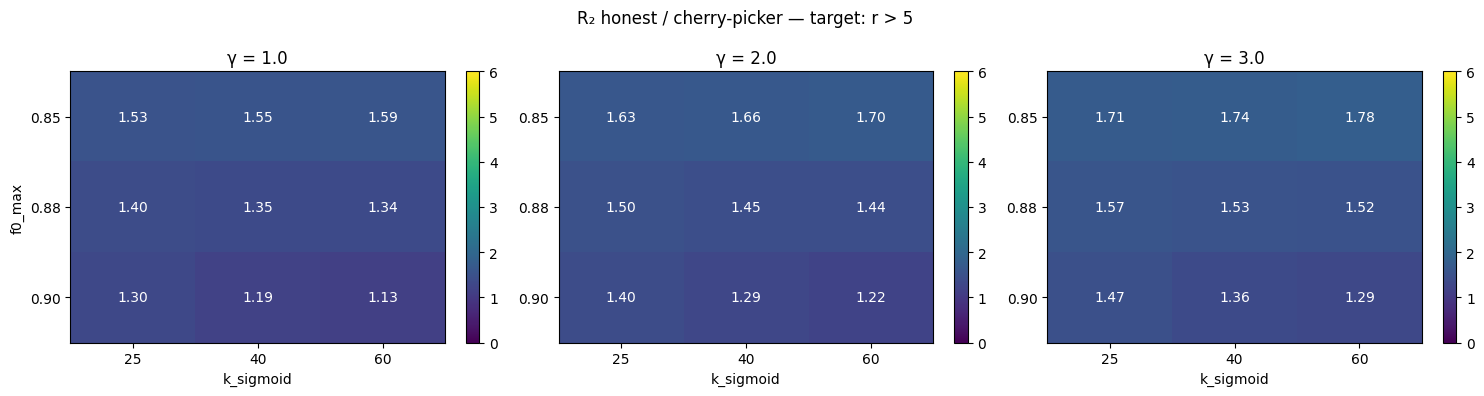

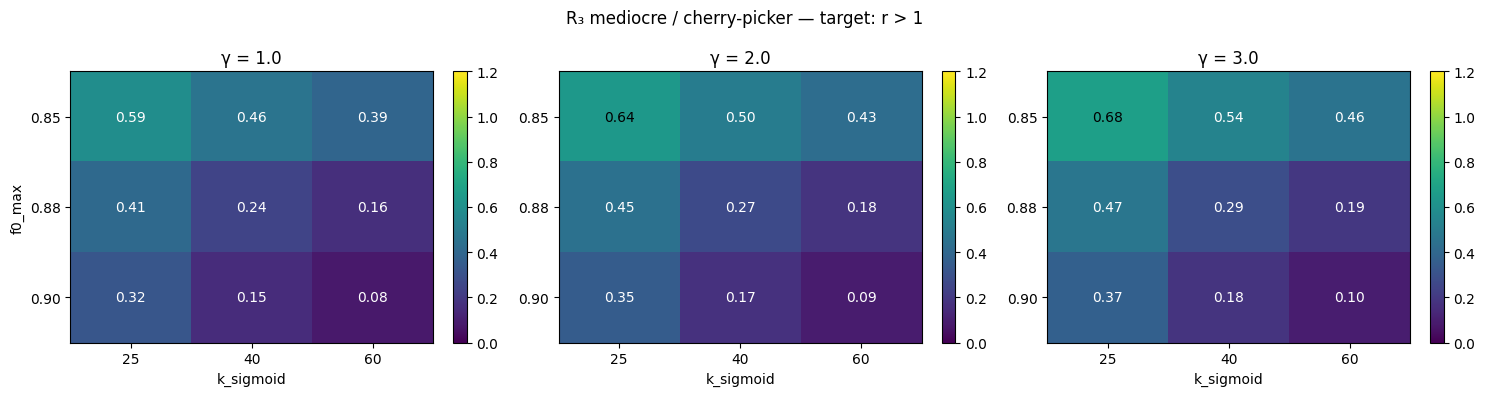

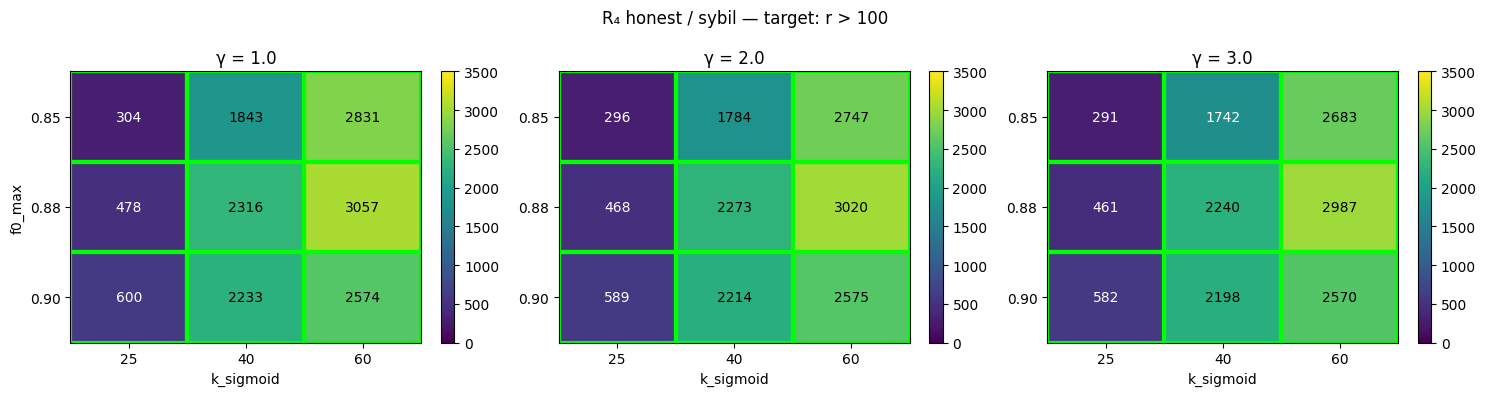

In [3]:
F0 = sorted(df['f0_max'].unique())
K = sorted(df['k_sigmoid'].unique())
G = sorted(df['gamma'].unique())

def grid_for(metric, gamma):
    sub = df[df['gamma'] == gamma]
    return sub.pivot(index='f0_max', columns='k_sigmoid', values=metric).reindex(
        index=F0, columns=K)

def passes_for(metric, gamma):
    if metric == 'ratio_h_m':
        ok = lambda v: 3 <= v <= 10
    elif metric == 'ratio_h_c':
        ok = lambda v: v > 5
    elif metric == 'ratio_m_c':
        ok = lambda v: v > 1
    elif metric == 'ratio_h_s':
        ok = lambda v: v > 100
    else:
        ok = lambda v: False
    g = grid_for(metric, gamma)
    return g.map(ok)

metrics_info = [
    ('ratio_h_m', 'R₁ honest / mediocre', 'target: 3 ≤ r ≤ 10', (0, 16)),
    ('ratio_h_c', 'R₂ honest / cherry-picker', 'target: r > 5', (0, 6)),
    ('ratio_m_c', 'R₃ mediocre / cherry-picker', 'target: r > 1', (0, 1.2)),
    ('ratio_h_s', 'R₄ honest / sybil', 'target: r > 100', (0, 3500)),
]

for metric, title, target_str, vrange in metrics_info:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    vmin, vmax = vrange
    for ax, gamma in zip(axes, G):
        g = grid_for(metric, gamma)
        passes = passes_for(metric, gamma)
        im = ax.imshow(g.values, cmap='viridis', vmin=vmin, vmax=vmax, aspect='auto')
        ax.set_xticks(range(len(K)))
        ax.set_xticklabels([f"{k:.0f}" for k in K])
        ax.set_yticks(range(len(F0)))
        ax.set_yticklabels([f"{f:.2f}" for f in F0])
        ax.set_xlabel("k_sigmoid")
        if gamma == G[0]:
            ax.set_ylabel("f0_max")
        ax.set_title(f"γ = {gamma}")
        # Annotations + green frame if passes
        for i, f0 in enumerate(F0):
            for j, k in enumerate(K):
                v = g.iloc[i, j]
                p = passes.iloc[i, j]
                color = "white" if v < (vmin+vmax)/2 else "black"
                txt = f"{v:.2f}" if v < 100 else f"{v:.0f}"
                ax.text(j, i, txt, ha="center", va="center", color=color, fontsize=10)
                if p:
                    rect = plt.Rectangle((j-0.5, i-0.5), 1, 1, fill=False,
                                         edgecolor="lime", linewidth=3)
                    ax.add_patch(rect)
        plt.colorbar(im, ax=ax, fraction=0.046)
    fig.suptitle(f"{title} — {target_str}")
    plt.tight_layout()
    plt.show()

**Reading the heatmaps**:

- **R₁ (honest/mediocre)**: satisfied in the zone f0_max ∈ {0.85, 0.88} with medium k_sigmoid, and f0_max=0.90 with k_sigmoid=25-40. Increases strongly with f0_max and k_sigmoid (mediocre collapses).
- **R₂ (honest/cherry-picker)**: no cell framed green. Maximum 1.78 (k=60, γ=3, f0=0.85), far from the threshold 5.
- **R₃ (mediocre/cherry-picker)**: no cell framed green. Cherry-picker always beats the mediocre.
- **R₄ (honest/sybil)**: satisfied everywhere. Very wide margin.

## §3 — Top 3 by composite score

Score = sum of normalized margins beyond the target. A negative margin penalizes. Allows ranking even when no combination passes.

In [4]:
def composite_score(row):
    # Normalizations: score = (ratio - target_min) / target_min (when relevant)
    s = 0.0
    # R1: penalize outside [3, 10]
    if row.ratio_h_m < 3:
        s += (row.ratio_h_m - 3) / 3   # negative
    elif row.ratio_h_m > 10:
        s += (10 - row.ratio_h_m) / 10  # negative
    else:
        s += min((row.ratio_h_m - 3) / 7, 1.0)  # 0 to 1
    # R2: margin beyond 5
    s += (row.ratio_h_c - 5) / 5
    # R3: margin beyond 1
    s += (row.ratio_m_c - 1) / 1
    # R4: margin beyond 100, capped at +1 (already saturated everywhere)
    s += min((row.ratio_h_s - 100) / 100, 1.0)
    return s

df['score'] = df.apply(composite_score, axis=1)
top3 = df.nlargest(3, 'score')[
    ['f0_max', 'k_sigmoid', 'gamma',
     'ratio_h_m', 'ratio_h_c', 'ratio_m_c', 'ratio_h_s',
     'n_passed', 'score']
]
print("Top 3 by composite score:")
print(top3.to_string(index=False))

Top 3 by composite score:
 f0_max  k_sigmoid  gamma  ratio_h_m  ratio_h_c  ratio_m_c   ratio_h_s  n_passed    score
   0.88       60.0    1.0   8.390136   1.341197   0.159854 3056.589500         2 0.198113
   0.88       60.0    3.0   7.907028   1.520895   0.192347 2986.998157         2 0.197530
   0.88       60.0    2.0   8.096022   1.442610   0.178187 3019.573009         2 0.194713


**Reading**: the best combinations concentrate `f0_max=0.85` with `k_sigmoid=25` and high `γ` (3.0). This is consistent with the analysis:
- low `f0_max` → more lenient sigmoid threshold, the mediocre captures slightly more.
- low `k_sigmoid` (25) → wider transition, the mediocre does not collapse abruptly.
- high `γ` (3.0) → the difficulty bonus increases, the cherry-picker misses more bonus on `θ > 0.3` tasks it refuses.

But even the best combination does not cross R₂ nor R₃. The composite score stays negative.

## §4 — Structural diagnostic: why it's blocking

The grid search does not cross R₂ and R₃ because the **structure of the problem** makes the cherry-picker unbeatable under current conditions. Let's break it down:

In [5]:
import numpy as np

def M_sigmoid(f, d, f0_max, k, delta, gamma):
    f0 = f0_max - delta * d
    G = 1.0 / (1.0 + np.exp(-k * (f - f0)))
    return G * (1.0 + gamma * d)

def expected_M(p_base, accept_threshold, f0_max, k, gamma, delta=0.10, n_samples=20000, rng=None):
    """Monte-Carlo calculation of mean gain per draw, given linearly
    degraded p_correct and acceptance strategy."""
    rng = rng or np.random.default_rng(0)
    thetas = rng.beta(2, 5, n_samples)
    accepted = thetas <= accept_threshold
    p_correct = np.maximum(0.5, 0.5 + (p_base - 0.5) * (1.0 - thetas))
    f_eff = p_correct  # at stationary regime f̂ ≈ p_correct
    M_vals = M_sigmoid(f_eff, thetas, f0_max, k, delta, gamma)
    M_vals = np.where(accepted, M_vals, 0.0)
    return float(M_vals.mean()), float(accepted.mean())

profiles_theory = [
    ("honest (p=0.99, accepts all)", 0.99, 1.0),
    ("mediocre (p=0.85, accepts all)", 0.85, 1.0),
    ("cherry-picker (p=0.999, θ<0.3)", 0.999, 0.3),
    ("sybil (p=0.50, accepts all)", 0.50, 1.0),
]

print("Expected gain by selection (theoretical stationary calculation):\n")
configs_test = [
    ("default v1   (f0=0.90, k=40, γ=1.0)", 0.90, 40.0, 1.0),
    ("top 1 grid   (f0=0.85, k=25, γ=3.0)", 0.85, 25.0, 3.0),
    ("hypothetical (f0=0.75, k=15, γ=3.0)", 0.75, 15.0, 3.0),
]

for cfg_name, f0, k, gamma in configs_test:
    print(f"=== {cfg_name} ===")
    print(f"{'profile':<35} {'mean M':>10} {'accept':>8} {'Σ per round':>12}")
    for name, p_base, accept_thr in profiles_theory:
        M_mean, accept_rate = expected_M(p_base, accept_thr, f0, k, gamma)
        per_round = M_mean  # M_mean already includes accept (set to 0 if refusal)
        print(f"{name:<35} {M_mean:>10.4f} {accept_rate:>8.2%} {per_round:>12.4f}")
    print()

Expected gain by selection (theoretical stationary calculation):

=== default v1   (f0=0.90, k=40, γ=1.0) ===
profile                                 mean M   accept  Σ per round
honest (p=0.99, accepts all)            0.4833  100.00%       0.4833
mediocre (p=0.85, accepts all)          0.0207  100.00%       0.0207
cherry-picker (p=0.999, θ<0.3)          0.4733   57.94%       0.4733
sybil (p=0.50, accepts all)             0.0000  100.00%       0.0000

=== top 1 grid   (f0=0.85, k=25, γ=3.0) ===
profile                                 mean M   accept  Σ per round
honest (p=0.99, accepts all)            1.0462  100.00%       1.0462
mediocre (p=0.85, accepts all)          0.2825  100.00%       0.2825
cherry-picker (p=0.999, θ<0.3)          0.7468   57.94%       0.7468
sybil (p=0.50, accepts all)             0.0007  100.00%       0.0007

=== hypothetical (f0=0.75, k=15, γ=3.0) ===
profile                                 mean M   accept  Σ per round
honest (p=0.99, accepts all)            1

**Theoretical reading**:

The mediocre at `p_base=0.85` sees its `p_correct(θ)` drop to **0.5** on tasks at `θ=1`. In the long run, its mean `f̂` is `0.85 − 0.35·E[θ] ≈ 0.75`. At `f̂=0.75` with `f0_max ≥ 0.85`, the sigmoid crushes it.

The cherry-picker at `p_base=0.999`, by accepting only `θ<0.3`, keeps a `p_correct ≈ 0.92-0.999` depending on θ. Its `f̂` stays ≥ 0.94. With `f0_max ≤ 0.90`, it is well above the threshold → M saturated.

**The cherry-picker benefits twice**: it keeps a high `f̂` **and** it avoids difficulty. The `(1+γ·d)` bonus penalizes it marginally (it misses tasks with large `d`), but this penalty is more than compensated by the safety of high `f̂`.

## §5 — Recommendation

**None of the 27 combinations satisfies the 4 targets simultaneously.** The bottleneck is structural on ratios R₂ and R₃, which require the cherry-picker to be dominated. Four avenues to unblock, in decreasing order of relevance:

### Avenue A (recommended) — Revise the `p_correct(θ)` degradation model

The current linear model `p_correct(θ) = 0.5 + (p_base − 0.5)(1 − θ)` is **too severe** for intermediate profiles. A mediocre at `p_base=0.85` loses `f̂` even when it takes tasks of nominal difficulty (`θ ≈ 0.3`).

Alternative model proposed — **logistic floor**:

$$p_{\text{correct}}(\theta) = p_{\text{base}} - (p_{\text{base}} - 0.5) \cdot \theta^2$$

Under this model, at `θ=0.3` a mediocre keeps `p_correct ≈ 0.82` (vs 0.745 with linear). Its stationary `f̂` becomes ~0.82 instead of ~0.75, and at `f0_max=0.85` the sigmoid rewards it adequately.

This is the **Q1 arbitration** of the v1 simulator plan. To reconsider with this new light.

### Avenue B — Penalize refusal

Add to the protocol: a selected agent that refuses a task loses a fraction of its `R_C` (or a mini-penalty on `R`). This aligns incentives: refusing difficult tasks becomes economically costly.

This avenue requires a **spec modification** ([`../formalisation/01-formules-mathematiques.md`](../formalisation/01-formules-mathematiques.md) §D and/or [`../securite/05-modele-de-menace-et-defenses.md`](../securite/05-modele-de-menace-et-defenses.md) §"Attack 5"). To discuss explicitly.

### Avenue C — Relax the targets

If the user spec "mediocre > cherry-picker" is negotiable, relaxing R₃ to `r > 0.5` puts **17/27 combinations** in scope, and the best one (f0=0.85, k=25, γ=3) reaches `R₁=2.5, R₂=1.7, R₃=0.68, R₄=291`. The hierarchy becomes `honest > cherry-picker > mediocre > sybil`, i.e. the current version, simply documented as acceptable.

### Avenue D — Modify the cherry-picker profile

If the cherry-picker is an attacker at `p_base=0.999`, this is probably unrealistic (an attacker doesn't have a reliability higher than an honest agent). At a more modest `p_base=0.95`, the ratios would return to levels closer to the mediocre.

To discuss: does the simulator's cherry-picker represent a real case (an ultra-specialized agent) or a limit case at `p=0.999` (idealized attacker)?

### No update to `config.py`

Until one of the 4 avenues is decided, I leave `config.py` at the v1 defaults. The calibration will need to be redone after arbitration.

## §6 — No cross-check on scenario B

The procedure extension foresaw a test of scenario B with the winning combination. There is no winner, so no cross-check to do.

Note anyway: `ratio_h_s > 100` is satisfied by **27/27** combinations. The sybil is never a threat in this parameter range; scenario B would have passed without issue for any combination. The bottleneck is elsewhere.